# SEEDS - 2 - Soil Health Search

This notebook combines and formalizes soil data in **Leeds**. 

The workflow is designed to be adaptable for any UK local authority, which is selected at the beginning of the notebook. However, as this project focuses on Leeds, several datasets are sourced for the region tile (not whole of UK), making parts of the analysis project-specific.

Where possible, the notebook automatically retrieves the most up-to-date available data. Some datasets are however static and have not been updated for several years, these must thus be dowloaded manually.

In [27]:
pip install matplotlib mapclassify geopandas numpy scipy folium plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import folium
import mapclassify
import os

In [29]:
#Save paths of local computer and workspace in VS Code
#This allows to save processed datasets later on
RAW_DATA_DIR= r"C:\Users\qxnq723\Desktop\Project_2\Raw_Data"
PROCESSED_DATA_DIR= r"C:\Users\qxnq723\Desktop\Project_2\Processed_Data"
workspace_path= r"C:\Users\qxnq723\Desktop\Project_2\Dashboard Development"

In [30]:
#Choose Local Authority to work with
LOCAL_AUTHORITY_NAME = 'Leeds' 

output_file = f'output_{LOCAL_AUTHORITY_NAME}.gpkg'

## 1- Define Local Authority Boundaries

The UK local authorities boundaries data was downloaded from [geoportal](https://geoportal.statistics.gov.uk/datasets/ons::local-authority-districts-may-2024-boundaries-uk-bfe-2/explore?location=53.495068%2C-0.354857%2C7).
The UK data is subsetted to only include the boundaries of the local authority chosen at the start, in the case of this study Leeds is chosen.

In [31]:
# UK local authorities file path
UK_LAD_PATH = f"{RAW_DATA_DIR}/Local_Authority_Districts_May_2024_Boundaries_UK_BFE_6583563793708892075/LAD_MAY_2024_UK_BFE.shp"

print(f"Configured for: {LOCAL_AUTHORITY_NAME}")

Configured for: Leeds


In [32]:
# Load UK Local Authority District boundaries
print("Loading UK Local Authority District boundaries...")
LAD_2024 = gpd.read_file(UK_LAD_PATH)

print(f"Loaded {len(LAD_2024)} local authority districts")
print(f"Available LADs include: {sorted(LAD_2024['LAD24NM'].unique())[:10]}...")

# Check if our chosen LAD exists 
if LOCAL_AUTHORITY_NAME in LAD_2024['LAD24NM'].values:
    print(f"Found {LOCAL_AUTHORITY_NAME} in the dataset")
    target_lad = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
    print(f"Area: {target_lad.to_crs('EPSG:27700').geometry.area.iloc[0]/1000000:.2f} km²")
else:
    print(f"{LOCAL_AUTHORITY_NAME} not found in dataset")
    print("Available LADs:", sorted(LAD_2024['LAD24NM'].unique()))

Loading UK Local Authority District boundaries...
Loaded 361 local authority districts
Available LADs include: ['Aberdeen City', 'Aberdeenshire', 'Adur', 'Amber Valley', 'Angus', 'Antrim and Newtownabbey', 'Ards and North Down', 'Argyll and Bute', 'Armagh City, Banbridge and Craigavon', 'Arun']...
Found Leeds in the dataset
Area: 551.70 km²


<Axes: >

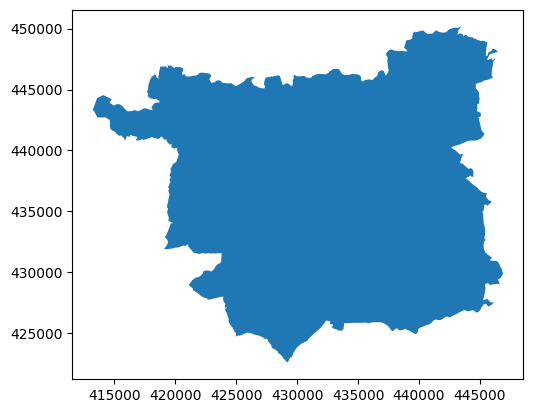

In [33]:
#Keep only chosen LA and plot it
chosen_LA = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
chosen_LA.plot()

In [34]:
#Check CRS
print(chosen_LA.crs)

EPSG:27700


In [35]:
#Create outline of chosen LA
chosen_LA['outline'] = 1
LA_outline = chosen_LA.dissolve(by= 'outline')

A function is created to subset datasets to the chosen local authority boundaries.

In [36]:
#Create function to subset data to the chosen LA
def subset_to_LAD(LAD_gdf, LAD_column_name, LAD_name, data_to_subset):
    """
    Subset a greenspace (or similar file) to only include greenspaces 
    within a chosen local authority.
    
    Parameters
    ----------
    LAD_gdf : geopandas.GeoDataFrame
        GeoDataFrame containing local authority district boundaries
    LAD_column_name : str
        Name of the column containing LAD names
    LAD_name : str
        Name of the specific LAD to subset to
    data_to_subset : geopandas.GeoDataFrame
        Data to be subset to the chosen LAD
        
    Returns
    -------
    geopandas.GeoDataFrame
        Data subset to only include features within the chosen LAD
    """
    chosen_LAD = LAD_gdf.loc[LAD_gdf[LAD_column_name] == LAD_name, :]
    chosen_LAD = chosen_LAD.to_crs(data_to_subset.crs)
    data_subset_to_LAD = data_to_subset[data_to_subset.within(chosen_LAD.union_all())]
    return data_subset_to_LAD

## 2- Geological Data - Digimap

The following geological data is downloaded from [British Geological Survey](https://www.bgs.ac.uk/datasets/soil-parent-material-model/#access).

In [37]:
#Open all shapefiles in folder
soil_parent = gpd.read_file(f"{RAW_DATA_DIR}\BGS_Soil_Parent_Material_V1_1km.gpkg")
soil_parent.info()

c:\Users\qxnq723\Desktop\Project_2\Dashboard Development\venv\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'BGS_Soil_Parent_Material_V1_1km.gpkg': 'Carbonate Content' (default), 'European Soil Bureau Description', 'Parent Material Grainsize', 'Soil_Depth', 'Soil Group', 'Soil Texture', 'layer_styles'. Specify layer parameter to avoid this warning.
  result = read_func(


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 241514 entries, 0 to 241513
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   ESB_DESC    241514 non-null  str     
 1   CARB_CNTNT  241514 non-null  str     
 2   PMM_GRAIN   241514 non-null  str     
 3   SOIL_GROUP  241514 non-null  str     
 4   SOIL_TEX    241514 non-null  str     
 5   SOIL_DEPTH  241514 non-null  str     
 6   PMM1K_UID   241514 non-null  str     
 7   VERSION     241514 non-null  str     
 8   geometry    241514 non-null  geometry
dtypes: geometry(1), str(8)
memory usage: 16.6 MB


<Axes: >

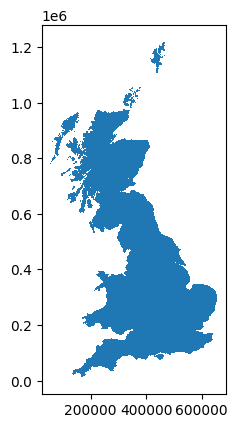

In [38]:
soil_parent.plot()

In [39]:
print(soil_parent.crs)

EPSG:27700


In [40]:
print(soil_parent.crs)

EPSG:27700


In [41]:
#Subset data to LA
soil_parent = gpd.clip(soil_parent, LA_outline)

In [42]:
soil_parent.head()

,ESB_DESC,CARB_CNTNT,PMM_GRAIN,SOIL_GROUP,SOIL_TEX,SOIL_DEPTH,PMM1K_UID,VERSION,geometry
177607,SANDSTONE,NONE,ARENACEOUS,LIGHT(SILTY) TO MEDIUM(SILTY) TO HEAVY,LOAM TO SANDY LOAM,SHALLOW,bgsn:SPMv1_1k_177608,DPSPM_V1_1km,"POLYGON ((439599.998 425000.004, 439799.998 42..."
177606,MUDSTONE AND SANDSTONE,NONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,CLAYEY LOAM TO SANDY LOAM,INTERMEDIATE-SHALLOW,bgsn:SPMv1_1k_177607,DPSPM_V1_1km,"POLYGON ((438999.996 425400, 438999.996 425600..."
180304,MUDSTONE AND SANDSTONE,NONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,CLAYEY LOAM TO SANDY LOAM,INTERMEDIATE-SHALLOW,bgsn:SPMv1_1k_180305,DPSPM_V1_1km,"POLYGON ((443999.999 427000.002, 444200 427000..."
178161,MUDSTONE AND SANDSTONE,NONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,CLAYEY LOAM TO SANDY LOAM,INTERMEDIATE-SHALLOW,bgsn:SPMv1_1k_178162,DPSPM_V1_1km,"POLYGON ((439999.999 425400, 439999.999 425600..."
178708,MUDSTONE AND SANDSTONE,NONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,CLAYEY LOAM TO SANDY LOAM,INTERMEDIATE-SHALLOW,bgsn:SPMv1_1k_178709,DPSPM_V1_1km,"POLYGON ((441000.001 425999.998, 441157.325 42..."


In [43]:
soil_parent['SOIL_GROUP'].value_counts()

SOIL_GROUP
MEDIUM TO HEAVY                           179
MEDIUM TO LIGHT(SILTY) TO HEAVY           143
LIGHT(SILTY) TO MEDIUM(SILTY)             130
LIGHT(SILTY) TO MEDIUM(SILTY) TO HEAVY     61
HEAVY TO MEDIUM                            55
ALL                                        43
LIGHT(SANDY) TO MEDIUM(SANDY)              22
MEDIUM TO LIGHT(SILTY)                      5
MEDIUM                                      3
MEDIUM(SILTY)                               1
Name: count, dtype: int64

In [44]:
soil_parent['PMM_GRAIN'].value_counts()

PMM_GRAIN
ARGILLIC - ARENACEOUS         336
MIXED (ARGILLIC-RUDACEOUS)    176
ARENACEOUS                    107
ARENACEOUS - RUDACEOUS         20
ARGILLACEOUS                    2
PEAT                            1
Name: count, dtype: int64

In [45]:
soil_parent['ESB_DESC'].value_counts()

ESB_DESC
MUDSTONE AND SANDSTONE                            192
GLACIAL TILL                                      171
SANDSTONE                                         107
DOLOSTONE                                          98
RIVERINE CLAY AND FLOODPLAIN SANDS AND GRAVEL      42
RIVER TERRACE SAND/GRAVEL                          16
UNCONSOLIDATED FLUVIAL AND GLACIGENIC DEPOSITS      5
GLACIOFLUVIAL DEPOSITS                              4
LIMESTONE                                           3
COLLUVIUM                                           1
CLAYSTONE/MUDSTONE                                  1
GLACIOLACUSTRINE                                    1
PEAT                                                1
Name: count, dtype: int64

In [46]:
soil_parent['SOIL_TEX'].value_counts()

SOIL_TEX
CLAYEY LOAM TO SILTY LOAM    171
LOAM TO CLAY                 119
LOAM TO SILTY                 98
CLAYEY LOAM TO SANDY LOAM     77
LOAM TO SANDY LOAM            73
CLAY TO SANDY LOAM            42
SAND TO SANDY LOAM            32
SILTY LOAM TO SANDY LOAM      22
VARIED, LOCALLY PEATY          5
SILTY LOAM                     1
CLAY TO CLAYEY LOAM            1
PEAT                           1
Name: count, dtype: int64

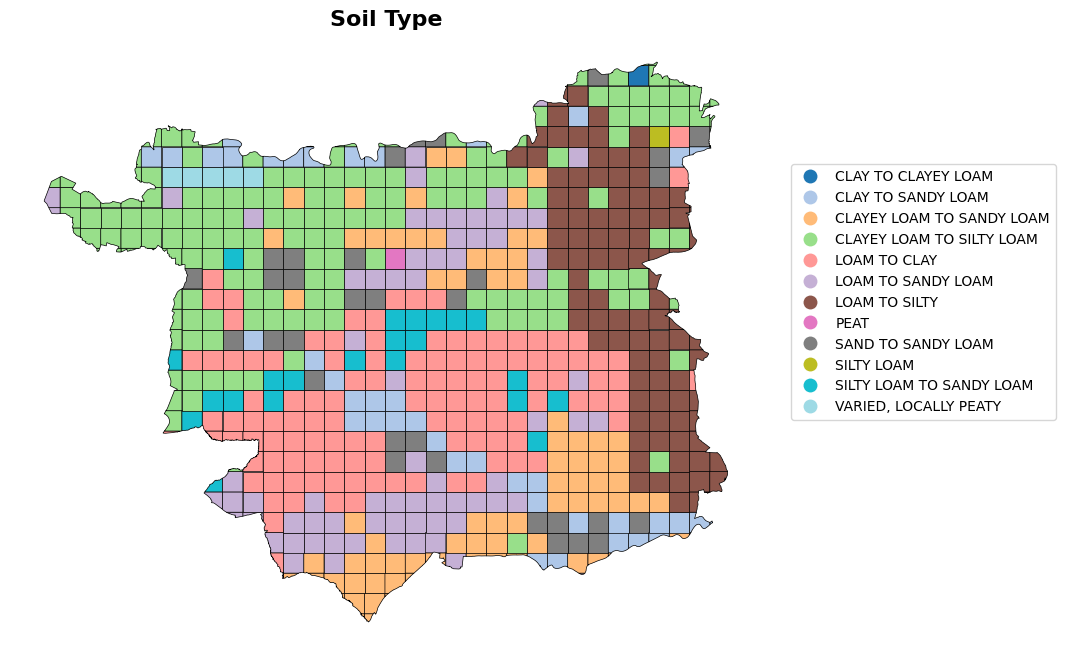

In [47]:
#Create map of soil type

#Choose which description to map
column = 'SOIL_TEX'

fig, ax = plt.subplots(figsize=(10, 8))

soil_parent.plot(column = column,
                 categorical= True,
                 legend = True,
                 cmap= 'tab20',
                 edgecolor= 'black',
                 linewidth= 0.5,
                 ax= ax,
                 legend_kwds= {
                     'loc': 'upper right',
                     'bbox_to_anchor': (1.4, 0.8)
                 }
)

ax.set_title('Soil Type', fontsize= 16, fontweight= 'bold')
ax.set_axis_off()
plt.show()

In [48]:
#Create soil metric column
soil_parent['Soil_Metric'] = 'Soil Parent'

In [49]:
#Adding description to GEN_GRAIN
dic= {
    "ARGILLIC - ARENACEOUS": "A layered subsoil of clay, silt and sand.",
    "ARENACEOUS": "A sand-rich subsoil.",
    "MIXED (ARGILLIC-RUDACEOUS)": "A variable clay, silt, and sand subsoil.",
    "ARENACEOUS - RUDACEOUS": "A layered subsoil of sand and gravel.",
    "ARGILLACEOUS": "A layered subsoil of clay.",
    "PEAT": "Organic peaty subsoil."
}

soil_parent["GEN_GRAIN_Desc"] = soil_parent["PMM_GRAIN"].map(dic)
soil_parent = soil_parent.rename(columns={"PMM_GRAIN": "GEN_GRAIN"})
soil_parent.head()

,ESB_DESC,CARB_CNTNT,GEN_GRAIN,SOIL_GROUP,SOIL_TEX,SOIL_DEPTH,PMM1K_UID,VERSION,geometry,Soil_Metric,GEN_GRAIN_Desc
177607,SANDSTONE,NONE,ARENACEOUS,LIGHT(SILTY) TO MEDIUM(SILTY) TO HEAVY,LOAM TO SANDY LOAM,SHALLOW,bgsn:SPMv1_1k_177608,DPSPM_V1_1km,"POLYGON ((439599.998 425000.004, 439799.998 42...",Soil Parent,A sand-rich subsoil.
177606,MUDSTONE AND SANDSTONE,NONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,CLAYEY LOAM TO SANDY LOAM,INTERMEDIATE-SHALLOW,bgsn:SPMv1_1k_177607,DPSPM_V1_1km,"POLYGON ((438999.996 425400, 438999.996 425600...",Soil Parent,"A layered subsoil of clay, silt and sand."
180304,MUDSTONE AND SANDSTONE,NONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,CLAYEY LOAM TO SANDY LOAM,INTERMEDIATE-SHALLOW,bgsn:SPMv1_1k_180305,DPSPM_V1_1km,"POLYGON ((443999.999 427000.002, 444200 427000...",Soil Parent,"A layered subsoil of clay, silt and sand."
178161,MUDSTONE AND SANDSTONE,NONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,CLAYEY LOAM TO SANDY LOAM,INTERMEDIATE-SHALLOW,bgsn:SPMv1_1k_178162,DPSPM_V1_1km,"POLYGON ((439999.999 425400, 439999.999 425600...",Soil Parent,"A layered subsoil of clay, silt and sand."
178708,MUDSTONE AND SANDSTONE,NONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,CLAYEY LOAM TO SANDY LOAM,INTERMEDIATE-SHALLOW,bgsn:SPMv1_1k_178709,DPSPM_V1_1km,"POLYGON ((441000.001 425999.998, 441157.325 42...",Soil Parent,"A layered subsoil of clay, silt and sand."


## 3- Land cover - Digimap

The 2024 land cover data for the SE tile was downloaded from [Digimap Environment](https://digimap.edina.ac.uk/roam/map/environment),  with the underlying dataset provided by the [UK Centre for Ecology & Hydrology (UKCEH)](https://catalogue.ceh.ac.uk/documents/d036a1c2-77b2-40ef-a14d-d21fb394b595).

In [50]:
#Load file
LandCover = gpd.read_file(rf"{RAW_DATA_DIR}\UKCEH_LandCover\lcm-2024-vec_6387524.gpkg")
LandCover.head()
print(LandCover.crs)

EPSG:27700


In [51]:
#Subset data to LA
LandCover = gpd.clip(LandCover, LA_outline)

In [52]:
#Convert the _mode to integer
LandCover['_mode'] = LandCover['_mode'].astype('Int64')

In [53]:
#Add column with land cover associated with each _mode

#Create list of identifiers (based on documentation)
LC_identifiers = {
    'Deciduous woodland': 1,
    'Coniferous woodland': 2,
    'Arable': 3,
    'Improve grassland': 4,
    'Neutral grassland': 5,
    'Calcareous grassland':	6,
    'Acid grassland': 7,
    'Fen': 8,
    'Heather': 9,
    'Heather grassland': 10,
    'Bog': 11,
    'Inland rock': 12,
    'Saltwater': 13,
    'Freshwater': 14,
    'Supralittoral rock': 15,
    'Supralittoral sediment': 16,
    'Littoral  rock': 17,
    'Littoral sediment': 18,
    'Saltmarsh': 19,
    'Urban': 20,
    'Suburban': 21
}

#Reverse dictionary: ID to label
id_to_label = {v: k for k, v in LC_identifiers.items()}

#Create new column
LandCover['Land_Cover_Type'] = LandCover['_mode'].map(id_to_label)
LandCover.head()


,_conf,_hist,_mode,_n,_purity,_stdev,_agg,gid,geometry,Land_Cover_Type
261013,56.76,"1:9,3:9,4:135,20:2,21:14",4,169,79.88,22.56,4,5460832,"MULTIPOLYGON (((424823.61 425230.08, 424825.44...",Improve grassland
222059,57.88,"1:15,3:4,4:3,20:3,21:41",21,66,62.12,19.44,10,4643857,"POLYGON ((424845.391 425302.807, 424871.35 425...",Suburban
147252,62.08,"4:13,20:4,21:56",21,73,76.71,16.19,10,3087901,"MULTIPOLYGON (((424823.222 425229.929, 424816....",Suburban
309443,57.64,"1:9,3:36,4:49,20:12,21:175",21,281,62.28,21.82,10,6477587,"POLYGON ((424718.629 425342.699, 424723.698 42...",Suburban
177521,79.28,"4:71,21:43",4,114,62.28,20.26,4,3721705,"POLYGON ((424931.28 425538.854, 424828.41 4254...",Improve grassland


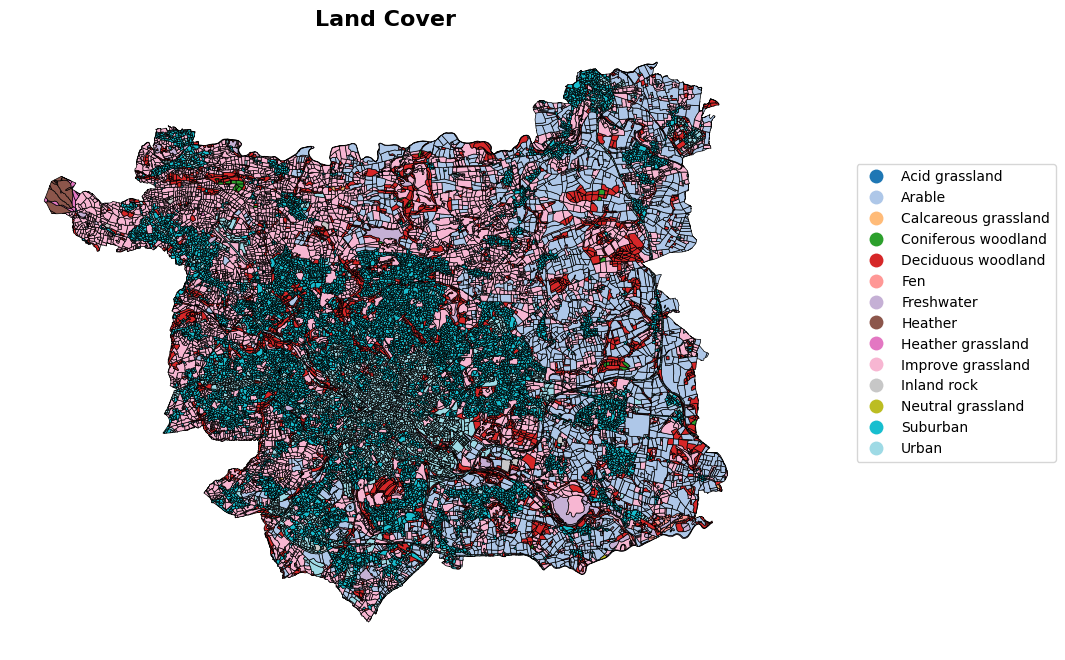

In [54]:
#Create map of land cover

fig, ax = plt.subplots(figsize=(10, 8))

LandCover.plot(column = 'Land_Cover_Type',
                 categorical= True,
                 legend = True,
                 cmap= 'tab20',
                 edgecolor= 'black',
                 linewidth= 0.5,
                 ax= ax,
                 legend_kwds= {
                     'loc': 'upper right',
                     'bbox_to_anchor': (1.4, 0.8)
                 }
)

ax.set_title('Land Cover', fontsize= 16, fontweight= 'bold')
ax.set_axis_off()
plt.show()

In [55]:
#Create soil metric column
LandCover['Soil_Metric'] = 'Land Cover'

## 4 - Soil Chemistry (Heavy Metals UKSO Data)

The heavy metals data was dowloaded for the whole of the UK from the [UKSO UK topsoil geochemistry dataset](https://www.ukso.org/static-maps/uk-topsoil-geochemistry.html), which combines data from five different topsoil survey projects spanning from 1978 to 2014.

In [56]:
pip install rasterio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
#Build one combined dataset with all heavy metals 
# and
#Convert Geotiff raster into vector polygons geometries

#Import libraries
import rasterio #to open GeoTIFF files and raster data
from rasterio.features import shapes #to convert raster to polygons
from pathlib import Path #file/folder handling

#Create path to folder with heavy metal files
folder_path = Path(rf'{RAW_DATA_DIR}/UKSO_HeavyMetals')

#Create empty list to contain the GeoDataFrames
all_gdfs = []

#Loop through every subfolder for tif files
for tif_path in folder_path.rglob("*.tif"):
    print(f"Processing: {tif_path.name}")
    
    #Extract name of heavymetal from subfolders string
    subfolder_name = tif_path.parent.name
    metal = subfolder_name.split('geotiff_')[1].split('_v1')[0]

    #Open GeoTIFF file, and read band 1 into array 
    # (TIFF files have only 1 band)
    with rasterio.open(tif_path) as source:
        raster = source.read(1)
        
        #Convert raster data into polygons
        # s = polygon geometry
        # v = raster value
        results = (
            {'properties': {'value': v}, 
             'geometry': s}
            for s , v in shapes(raster, transform= source.transform) # convert pixel coordinates into real-world coordinates
            if v != source.nodata #skip pixels with no data
        )


        #Convert all polygon features into list and then into a GeoDataFrame
        gdf= gpd.GeoDataFrame.from_features(list(results))
        #Assign UK 27700 CRS
        gdf.set_crs(source.crs, inplace= True)
        
        #Track source file
        gdf['source_file'] = tif_path.stem
        #Add metal name column
        gdf['metal'] = metal
        #Add the GeoDataFrame into master list (1 GeoDataFrame per TIFF)
        all_gdfs.append(gdf)

#Convert into big table
HeavyMetals = pd.concat(all_gdfs, ignore_index = True)
HeavyMetals = gpd.GeoDataFrame(HeavyMetals, geometry= 'geometry')
HeavyMetals.head()

Processing: As_v1.tif
Processing: Cd_v1.tif
Processing: Cu_v1.tif
Processing: Ni_v1.tif
Processing: P2O5_v1.tif
Processing: Pb_v1.tif
Processing: Se_v1.tif
Processing: Zr_v1.tif


,geometry,value,source_file,metal
0,"POLYGON ((239500 685500, 239500 685000, 240000...",13.14662,As_v1,As
1,"POLYGON ((240500 685500, 240500 685000, 241000...",13.33386,As_v1,As
2,"POLYGON ((239500 685000, 239500 684500, 240000...",13.33047,As_v1,As
3,"POLYGON ((240000 685000, 240000 684500, 240500...",13.56266,As_v1,As
4,"POLYGON ((240500 685000, 240500 684500, 241000...",13.60579,As_v1,As


In [58]:
HeavyMetals.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5341907 entries, 0 to 5341906
Data columns (total 4 columns):
 #   Column       Dtype   
---  ------       -----   
 0   geometry     geometry
 1   value        float64 
 2   source_file  str     
 3   metal        str     
dtypes: float64(1), geometry(1), str(2)
memory usage: 163.0 MB


In [59]:
HeavyMetals['metal'].value_counts()

metal
Ni      672307
As      672292
Pb      672266
Zr      672259
Se      672245
Cu      671982
Cd      671776
P2O5    636780
Name: count, dtype: int64

In [60]:
#Subset data to LA
HeavyMetals = gpd.clip(HeavyMetals, LA_outline)

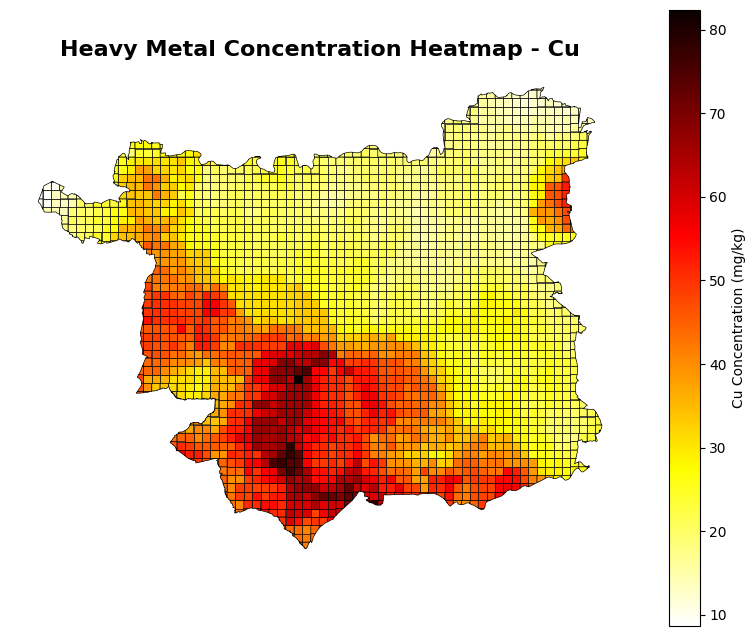

In [61]:
#Create map of heavy metal

#Choose which heavy metal to map
plot_metal = 'Cu'
#Filter dataset for that metal only
m = HeavyMetals[HeavyMetals['metal'] == plot_metal]

fig, ax = plt.subplots(figsize=(10, 8))

m.plot(column = 'value',
       legend = True,
       cmap= 'hot_r',
       edgecolor= 'black',
       linewidth= 0.5,
       ax= ax,
       legend_kwds= {'label': f'{plot_metal} Concentration (mg/kg)'}
)

ax.set_title(f'Heavy Metal Concentration Heatmap - {plot_metal}', 
             fontsize= 16, 
             fontweight= 'bold')
ax.set_axis_off()
plt.show()

In [62]:
#Add the unit of each heavy metal (are not all the same)
units= {
    'Ni': 'mg/kg',
    'As': 'mg/kg',
    'Pb': 'mg/kg',
    'Zr': 'mg/kg',
    'Se': 'mg/kg',
    'Cu': 'mg/kg',
    'Cd': 'mg/kg',
    'P2O5': 'w%',
}

HeavyMetals['HM_unit'] = HeavyMetals['metal'].map(units)

In [63]:
#Add the unit of each heavy metal (are not all the same)
name_metal= {
    'Ni': 'Nickel',
    'As': 'Arsenic',
    'Pb': 'Lead',
    'Zr': 'Zirconium',
    'Se': 'Selenium',
    'Cu': 'Copper',
    'Cd': 'Cadmium',
    'P2O5': 'Phosphorus',
}

HeavyMetals['HM_name'] = HeavyMetals['metal'].map(name_metal)

In [64]:
#Create soil metric column
HeavyMetals['Soil_Metric'] = 'Heavy Metals'

In [65]:
HeavyMetals.head()

,geometry,value,source_file,metal,HM_unit,HM_name,Soil_Metric
2856930,"POLYGON ((421500 428500, 421500 428465.079, 42...",0.337968,P2O5_v1,P2O5,w%,Phosphorus,Heavy Metals
4179492,"POLYGON ((421500 428500, 421500 428465.079, 42...",1.213054,Se_v1,Se,mg/kg,Selenium,Heavy Metals
3507222,"POLYGON ((421500 428500, 421500 428465.079, 42...",104.994499,Pb_v1,Pb,mg/kg,Lead,Heavy Metals
4179095,"POLYGON ((421500 429000, 421500 428500, 421461...",1.212224,Se_v1,Se,mg/kg,Selenium,Heavy Metals
4850907,"POLYGON ((421500 429000, 421126.864 429000, 42...",197.167404,Zr_v1,Zr,mg/kg,Zirconium,Heavy Metals


Check how much of Leeds is above recommended heavy metal threshold.

In [66]:
#Import soil health thresholds
thresholds= pd.read_excel(f"{RAW_DATA_DIR}/Soil_health_Thresholds.xlsx")

In [67]:
#Merge the two datasets
gdf = HeavyMetals.merge(thresholds, on='metal', how='left')
gdf.head()

,geometry,value,source_file,metal,HM_unit,HM_name_x,Soil_Metric_x,Soil_Metric_y,Soil_Column,HM_name_y,RHS_lower,RHS_upper,NBC_threshold,C4SL_threshold,SGV_threshold,threshold_unit
0,"POLYGON ((421500 428500, 421500 428465.079, 42...",0.337968,P2O5_v1,P2O5,w%,Phosphorus,Heavy Metals,Heavy Metals,value,Phosphorus,NaN,NaN,NaN,NaN,NaN,NaN
1,"POLYGON ((421500 428500, 421500 428465.079, 42...",1.213054,Se_v1,Se,mg/kg,Selenium,Heavy Metals,Heavy Metals,value,Selenium,NaN,NaN,NaN,NaN,120.0,mg/kg
2,"POLYGON ((421500 428500, 421500 428465.079, 42...",104.994499,Pb_v1,Pb,mg/kg,Lead,Heavy Metals,Heavy Metals,value,Lead,NaN,NaN,180.0,80.0,NaN,mg/kg
3,"POLYGON ((421500 429000, 421500 428500, 421461...",1.212224,Se_v1,Se,mg/kg,Selenium,Heavy Metals,Heavy Metals,value,Selenium,NaN,NaN,NaN,NaN,120.0,mg/kg
4,"POLYGON ((421500 429000, 421126.864 429000, 42...",197.167404,Zr_v1,Zr,mg/kg,Zirconium,Heavy Metals,Heavy Metals,value,Zirconium,NaN,NaN,NaN,NaN,250.0,mg/kg


In [68]:
#Create exceedance columns
threshold_cols= [
    'NBC_threshold',
    'C4SL_threshold',
    'SGV_threshold'
]

for t in threshold_cols:
    gdf[t + '_exceed'] = (gdf['value'] > gdf[t]) & gdf[t].notna()
    
gdf.head()

,geometry,value,source_file,metal,HM_unit,HM_name_x,Soil_Metric_x,Soil_Metric_y,Soil_Column,HM_name_y,RHS_lower,RHS_upper,NBC_threshold,C4SL_threshold,SGV_threshold,threshold_unit,NBC_threshold_exceed,C4SL_threshold_exceed,SGV_threshold_exceed
0,"POLYGON ((421500 428500, 421500 428465.079, 42...",0.337968,P2O5_v1,P2O5,w%,Phosphorus,Heavy Metals,Heavy Metals,value,Phosphorus,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
1,"POLYGON ((421500 428500, 421500 428465.079, 42...",1.213054,Se_v1,Se,mg/kg,Selenium,Heavy Metals,Heavy Metals,value,Selenium,NaN,NaN,NaN,NaN,120.0,mg/kg,False,False,False
2,"POLYGON ((421500 428500, 421500 428465.079, 42...",104.994499,Pb_v1,Pb,mg/kg,Lead,Heavy Metals,Heavy Metals,value,Lead,NaN,NaN,180.0,80.0,NaN,mg/kg,False,True,False
3,"POLYGON ((421500 429000, 421500 428500, 421461...",1.212224,Se_v1,Se,mg/kg,Selenium,Heavy Metals,Heavy Metals,value,Selenium,NaN,NaN,NaN,NaN,120.0,mg/kg,False,False,False
4,"POLYGON ((421500 429000, 421126.864 429000, 42...",197.167404,Zr_v1,Zr,mg/kg,Zirconium,Heavy Metals,Heavy Metals,value,Zirconium,NaN,NaN,NaN,NaN,250.0,mg/kg,False,False,False


In [69]:
#Count number of polygons in Leeds above thresholds
summary = []

for t in threshold_cols:
    
    #Only keep rows where this threshold exists
    temp = gdf[gdf[t].notna()]
    
    #Count polygons above threshold
    counts = (
        temp
        .groupby('metal')[t + '_exceed']
        .sum()
        .rename('Polygons_count_above')
    )
    
    #Count total number of polygons for each metal
    totals= (
        temp
        .groupby('metal')
        .size()
        .rename('Total_polygons')   
    )
    
    #Combine the 2
    result= pd.concat([counts, totals], axis=1).reset_index()
    
    #Calculate percentage
    result['Percent_above']= (
        result['Polygons_count_above'] / result['Total_polygons'] * 100
    ).round(2)
    
    
    result['Threshold']= t
    
    summary.append(result)

summary = pd.concat(summary, ignore_index= True)
print(summary)

   metal  Polygons_count_above  Total_polygons  Percent_above       Threshold
0     As                   224            2390           9.37   NBC_threshold
1     Cd                    32            2389           1.34   NBC_threshold
2     Cu                   102            2390           4.27   NBC_threshold
3     Ni                    11            2390           0.46   NBC_threshold
4     Pb                     0            2390           0.00   NBC_threshold
5     As                    25            2390           1.05  C4SL_threshold
6     Cd                     0            2389           0.00  C4SL_threshold
7     Pb                   978            2390          40.92  C4SL_threshold
8     As                    53            2390           2.22   SGV_threshold
9     Cd                     0            2389           0.00   SGV_threshold
10    Cu                     0            2390           0.00   SGV_threshold
11    Se                     0            2390           0.00   

## 5- Soil pH - UKSO

The UK soil pH data was dowloaded from [UKSO topsoil pH](https://catalogue.ceh.ac.uk/documents/5dd624a9-55c9-4cc0-b366-d335991073c7), which were collected and analysed in 2007.

In [70]:
Soil_pH = gpd.read_file(rf'{RAW_DATA_DIR}/UKSO_Soil_pH/CS_topsoil_pH_bulkDensity.shp')
Soil_pH.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   LCM_CLASS   1385 non-null   str     
 1   LCM_NUMBER  1385 non-null   int32   
 2   DOM_GRAIN   1385 non-null   str     
 3   SOIL_GROUP  1385 non-null   str     
 4   CACO3_RANK  1385 non-null   str     
 5   BULKD_07    1385 non-null   float64 
 6   BULKD_07SE  1385 non-null   float64 
 7   PH_78       1385 non-null   float64 
 8   PH_78SE     1385 non-null   float64 
 9   PH_98       1385 non-null   float64 
 10  PH_98SE     1385 non-null   float64 
 11  PH_07       1385 non-null   float64 
 12  PH_07SE     1385 non-null   float64 
 13  SHAPE_AREA  1385 non-null   float64 
 14  SHAPE_LEN   1385 non-null   float64 
 15  geometry    1385 non-null   geometry
dtypes: float64(10), geometry(1), int32(1), str(4)
memory usage: 167.8 KB


In [71]:
print(Soil_pH.crs)

EPSG:27700


In [72]:
#Subset data to LA
Soil_pH = gpd.clip(Soil_pH, LA_outline)

In [73]:
Soil_pH.head()

,LCM_CLASS,LCM_NUMBER,DOM_GRAIN,SOIL_GROUP,CACO3_RANK,BULKD_07,BULKD_07SE,PH_78,PH_78SE,PH_98,PH_98SE,PH_07,PH_07SE,SHAPE_AREA,SHAPE_LEN,geometry
163,Broadleaved woodland,1,MUD,HEAVY TO MEDIUM,NONE,0.759731,0.023147,4.833214,0.099812,5.191102,0.101680,5.501506,0.063326,15000000.0,58000.0,"POLYGON ((439000 428000, 439000 429000, 440000..."
849,Arable and Horticulture,3,SAND,MEDIUM,HIGH,1.159905,0.018035,7.583729,0.085913,7.816203,0.080098,8.210084,0.069183,420000000.0,682000.0,"POLYGON ((445000 443000, 445000 443114.7, 4450..."
309,Improved Grassland,4,MUD,HEAVY TO MEDIUM,NONE,0.960654,0.018524,5.609945,0.054099,5.880890,0.053105,6.068252,0.036514,357000000.0,954000.0,"MULTIPOLYGON (((425000 425000, 425745.143 4250..."
273,Improved Grassland,4,SAND,MEDIUM TO LIGHT(SILTY),NONE,0.937116,0.016865,5.609945,0.054099,5.880890,0.053105,6.068252,0.036514,248000000.0,674000.0,"POLYGON ((428000 446000, 428000 446070.595, 42..."
119,Broadleaved woodland,1,SAND,LIGHT(SILTY) TO MEDIUM(SILTY) TO HEAVY,NONE,0.736193,0.022400,4.833214,0.099812,5.191102,0.101680,5.501506,0.063326,87000000.0,266000.0,"MULTIPOLYGON (((428000 438000, 428000 439000, ..."


PH_07 is the 'Mean value for total soil nitrogen concentration in 2007 modelled by LCM_CLASS and CACO3_RANK', so that is used as pH value and is mapped.

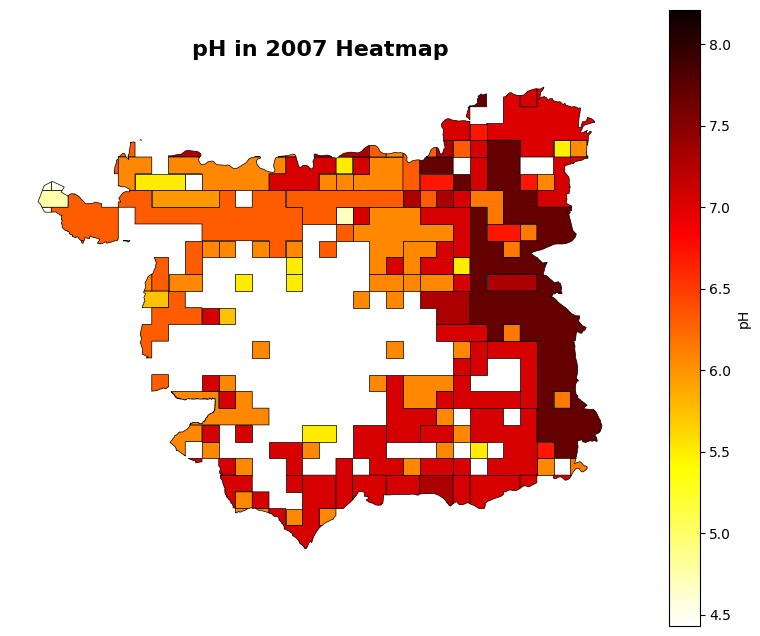

In [74]:
#Create map of pH in 2007

fig, ax = plt.subplots(figsize=(10, 8))

Soil_pH.plot(column = 'PH_07',
       legend = True,
       cmap= 'hot_r',
       edgecolor= 'black',
       linewidth= 0.5,
       ax= ax,
       legend_kwds= {'label': 'pH'}
)

ax.set_title(f'pH in 2007 Heatmap', 
             fontsize= 16, 
             fontweight= 'bold')
ax.set_axis_off()
plt.show()

In [75]:
#Create soil metric column
Soil_pH['Soil_Metric'] = 'Soil pH'

## 6- TopSoil Carbon - UKSO

The UK topsoil carbon was downloaded from [UKSO topsoil carbon](https://catalogue.ceh.ac.uk/documents/9e4451f8-23d3-40dc-9302-73e30ad3dd76), which was collected in 2007.

In [76]:
Soil_SOM = gpd.read_file(f'{RAW_DATA_DIR}/UKSO_SOM/CS_topsoil_carbon.shp')
Soil_SOM.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   LCM_CLASS   1385 non-null   str     
 1   LCM_NUMBER  1385 non-null   int32   
 2   DOM_GRAIN   1385 non-null   str     
 3   SOIL_GROUP  1385 non-null   str     
 4   CACO3_RANK  1385 non-null   str     
 5   CCONC_78    1385 non-null   float64 
 6   CCONC_78SE  1385 non-null   float64 
 7   CCONC_98    1385 non-null   float64 
 8   CCONC_98SE  1385 non-null   float64 
 9   CCONC_07    1385 non-null   float64 
 10  CCONC_07SE  1385 non-null   float64 
 11  LOI_78      1385 non-null   float64 
 12  LOI_78SE    1385 non-null   float64 
 13  LOI_98      1385 non-null   float64 
 14  LOI_98SE    1385 non-null   float64 
 15  LOI_07      1385 non-null   float64 
 16  LOI_07SE    1385 non-null   float64 
 17  CDENS_78    1385 non-null   float64 
 18  CDENS_78SE  1385 non-null   float64 
 19

In [77]:
print(Soil_SOM.crs)

EPSG:27700


In [78]:
#Subset data to LA
Soil_SOM = gpd.clip(Soil_SOM, LA_outline)

In [79]:
Soil_SOM.head()

,LCM_CLASS,LCM_NUMBER,DOM_GRAIN,SOIL_GROUP,CACO3_RANK,CCONC_78,CCONC_78SE,CCONC_98,CCONC_98SE,CCONC_07,...,LOI_07SE,CDENS_78,CDENS_78SE,CDENS_98,CDENS_98SE,CDENS_07,CDENS_07SE,SHAPE_AREA,SHAPE_LEN,geometry
28,Broadleaved woodland,1,MUD,HEAVY TO MEDIUM,NONE,57.224448,13.385675,100.833131,13.362104,81.514217,...,1.640902,66.159914,3.055434,77.350750,3.123253,68.529984,1.754334,1.500000e+07,58000.0,"POLYGON ((439000 428000, 439000 429000, 440000..."
96,Broadleaved woodland,1,SAND,LIGHT(SILTY) TO MEDIUM(SILTY),NONE,68.209941,13.239136,111.818624,13.216018,92.499710,...,1.611174,66.159914,3.055434,77.350750,3.123253,68.529984,1.754334,8.000000e+07,274000.0,"POLYGON ((431000 445000, 431000 445931.912, 43..."
538,Improved Grassland,4,SAND,LIGHT(SILTY) TO MEDIUM(SILTY),NONE,58.828651,7.699216,59.179935,7.512513,60.023892,...,1.064850,66.495364,1.619332,68.940971,1.554884,72.407370,0.969125,8.360000e+08,1896000.0,"MULTIPOLYGON (((423000 430000, 423000 429000, ..."
543,Arable and Horticulture,3,SAND,LIGHT(SILTY) TO MEDIUM(SILTY),NONE,35.747631,8.809080,34.060466,7.776545,32.416605,...,1.098951,52.520676,2.006340,51.872363,1.662541,49.672538,1.074950,1.046000e+09,2114000.0,"POLYGON ((439551.3 425000, 439551.3 425000, 43..."
223,Arable and Horticulture,3,MUD,HEAVY TO MEDIUM,NONE,24.762138,9.137334,23.074973,8.087917,21.431112,...,1.172104,52.520676,2.006340,51.872363,1.662541,49.672538,1.074950,9.080000e+08,1698000.0,"MULTIPOLYGON (((430000 424000, 430177.499 4240..."


LOI_07 is the 'Mean value for soil loss-on-ignition in 2007 modelled by LCM_CLASS and DOM_GRAIN', which corresponds to the soil organic matter (SOM).

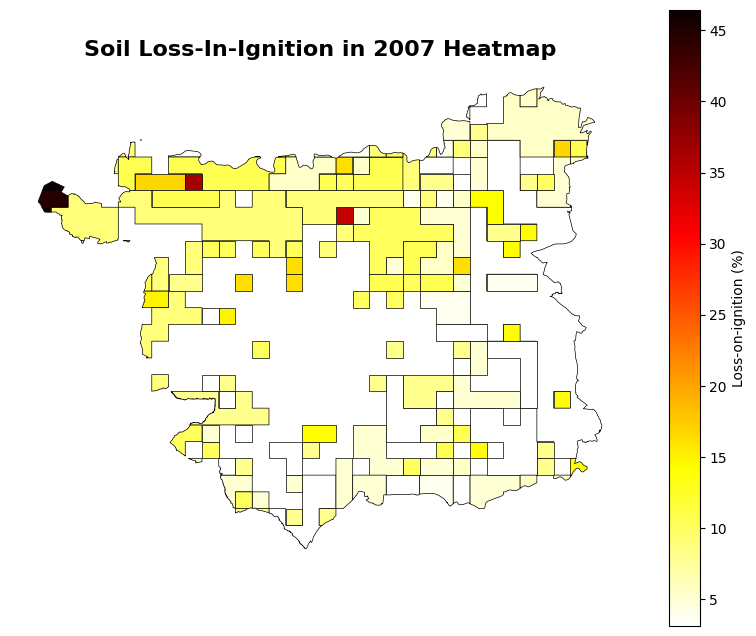

In [80]:
#Create map of SOM in 2007

fig, ax = plt.subplots(figsize=(10, 8))

Soil_SOM.plot(column = 'LOI_07',
       legend = True,
       cmap= 'hot_r',
       edgecolor= 'black',
       linewidth= 0.5,
       ax= ax,
       legend_kwds= {'label': 'Loss-on-ignition (%)'}
)

ax.set_title(f'Soil Loss-In-Ignition in 2007 Heatmap', 
             fontsize= 16, 
             fontweight= 'bold')
ax.set_axis_off()
plt.show()

In [81]:
#Create soil metric column
Soil_SOM['Soil_Metric'] = 'Soil SOM'

## 7- Create Clean Soil Health Dataset

The different datasets are combined into 1 clean soil health dataset:

In [82]:
print(soil_parent.crs)
print(LandCover.crs)
print(HeavyMetals.crs)
print(Soil_pH.crs)
print(Soil_SOM.crs)

EPSG:27700
EPSG:27700
PROJCS["OSGB36 / British National Grid",GEOGCS["OSGB36",DATUM["Ordnance_Survey_of_Great_Britain_1936",SPHEROID["Airy 1830",6377563.396,299.324964600004,AUTHORITY["EPSG","7001"]],AUTHORITY["EPSG","6277"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4277"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.9996012717],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","27700"]]
EPSG:27700
EPSG:27700


In [83]:
#Set the crs to 27700
HeavyMetals = HeavyMetals.to_crs("EPSG:27700")

In [84]:
Soil_pH.columns

Index(['LCM_CLASS', 'LCM_NUMBER', 'DOM_GRAIN', 'SOIL_GROUP', 'CACO3_RANK',
       'BULKD_07', 'BULKD_07SE', 'PH_78', 'PH_78SE', 'PH_98', 'PH_98SE',
       'PH_07', 'PH_07SE', 'SHAPE_AREA', 'SHAPE_LEN', 'geometry',
       'Soil_Metric'],
      dtype='str')

In [85]:
soil_parent['SOIL_GROUP'].unique()

<StringArray>
['LIGHT(SILTY) TO MEDIUM(SILTY) TO HEAVY',
                        'HEAVY TO MEDIUM',
          'LIGHT(SILTY) TO MEDIUM(SILTY)',
                                    'ALL',
                        'MEDIUM TO HEAVY',
        'MEDIUM TO LIGHT(SILTY) TO HEAVY',
          'LIGHT(SANDY) TO MEDIUM(SANDY)',
                                 'MEDIUM',
                          'MEDIUM(SILTY)',
                 'MEDIUM TO LIGHT(SILTY)']
Length: 10, dtype: str

In [86]:
soil_parent_to_join= soil_parent[['GEN_GRAIN', 'GEN_GRAIN_Desc', 'SOIL_GROUP', 'geometry', 'Soil_Metric']].copy()
LandCover_to_join= LandCover[['geometry', 'Land_Cover_Type','Soil_Metric']].copy()
HeavyMetals_to_join= HeavyMetals[['geometry', 'value', 'metal', 'HM_unit', 'HM_name', 'Soil_Metric']].copy()
Soil_pH_to_join= Soil_pH[['PH_07', 'geometry', 'Soil_Metric']]
Soil_SOM_to_join= Soil_SOM[['LOI_07', 'geometry', 'Soil_Metric']]

# Combine different soil health data
soil_health = pd.concat([soil_parent_to_join, LandCover_to_join, HeavyMetals_to_join, Soil_pH_to_join, Soil_SOM_to_join], ignore_index=True)
soil_health.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 45974 entries, 0 to 45973
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   GEN_GRAIN        642 non-null    str     
 1   GEN_GRAIN_Desc   642 non-null    str     
 2   SOIL_GROUP       642 non-null    str     
 3   geometry         45974 non-null  geometry
 4   Soil_Metric      45974 non-null  str     
 5   Land_Cover_Type  26549 non-null  str     
 6   value            18697 non-null  float64 
 7   metal            18697 non-null  str     
 8   HM_unit          18697 non-null  str     
 9   HM_name          18697 non-null  str     
 10  PH_07            43 non-null     float64 
 11  LOI_07           43 non-null     float64 
dtypes: float64(3), geometry(1), str(8)
memory usage: 4.2 MB


In [87]:
soil_health['Soil_Metric'].value_counts()

Soil_Metric
Land Cover      26549
Heavy Metals    18697
Soil Parent       642
Soil pH            43
Soil SOM           43
Name: count, dtype: int64

In [88]:
soil_health.head()

,GEN_GRAIN,GEN_GRAIN_Desc,SOIL_GROUP,geometry,Soil_Metric,Land_Cover_Type,value,metal,HM_unit,HM_name,PH_07,LOI_07
0,ARENACEOUS,A sand-rich subsoil.,LIGHT(SILTY) TO MEDIUM(SILTY) TO HEAVY,"POLYGON ((439599.998 425000.004, 439799.998 42...",Soil Parent,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ARGILLIC - ARENACEOUS,"A layered subsoil of clay, silt and sand.",HEAVY TO MEDIUM,"POLYGON ((438999.996 425400, 438999.996 425600...",Soil Parent,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ARGILLIC - ARENACEOUS,"A layered subsoil of clay, silt and sand.",HEAVY TO MEDIUM,"POLYGON ((443999.999 427000.002, 444200 427000...",Soil Parent,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ARGILLIC - ARENACEOUS,"A layered subsoil of clay, silt and sand.",HEAVY TO MEDIUM,"POLYGON ((439999.999 425400, 439999.999 425600...",Soil Parent,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARGILLIC - ARENACEOUS,"A layered subsoil of clay, silt and sand.",HEAVY TO MEDIUM,"POLYGON ((441000.001 425999.998, 441157.325 42...",Soil Parent,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8- Link Existing CGSs to their corresponding soil health

In [89]:
#Load the existing CGSs data
exist_CGS = gpd.read_file("../Data/Processed_Data/Existing_CGSs.gpkg")
exist_CGS.head()

,flag,Type,Name,Management,Organisation,Activity_Description,Entry_Conditions,Day_and_Time_(LGAP),Ongoing_or_set_programs?_(LGAP),All_year_or_seasonal?_(LGAP),...,Transport_Support_(LGAP),Contact_Name,Email,Phone_Number_(LGAP),Website_Link,Facebook_(FWC),Site_Accessibility_(LGAP)_Desc,Direction,id,geometry
0,FWL,Composting Collective,Chapel Allerton Composting In The Park,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Annie Whitehead OR Lukas and Katie at The Frui...,anniewhiteheadLeeds@gmail.com | Katy.daniel@ho...,NaN,NaN,NaN,NaN,https://www.google.com/maps/dir/?api=1&destina...,LEEDS_b4c70c92742e,POINT (-1.53365 53.83226)
1,FWL,Composting Collective,The Involve Centre,NaN,The Involve Centre,NaN,NaN,NaN,NaN,NaN,...,NaN,Annie Whitehead,anniewhiteheadLeeds@gmail.com |Penny@Involve.o...,NaN,NaN,NaN,NaN,https://www.google.com/maps/dir/?api=1&destina...,LEEDS_89f2ae8d6fb4,POINT (-1.52828 53.7801)
2,FWL,Composting Collective,Friends Of Hunslet Moor,NaN,Friends of Hunslet Moor Hub,NaN,NaN,NaN,NaN,NaN,...,NaN,Sam Gilmore,Sgilmore51@icloud.com,NaN,NaN,NaN,NaN,https://www.google.com/maps/dir/?api=1&destina...,LEEDS_27d9dc7ea461,POINT (-1.54174 53.78144)
3,FWL,Composting Collective,The Welcome In,NaN,OPAL (Older People's Active Learning Centre).,Now intergenerational with a toddler group.,NaN,NaN,NaN,NaN,...,NaN,Ellen Stoker,Ellen@opal-project.org.uk,NaN,NaN,NaN,NaN,https://www.google.com/maps/dir/?api=1&destina...,LEEDS_8fb02990b205,POINT (-1.61813 53.84896)
4,FWL,Composting Collective,Garforth,NaN,Incredible Edible,NaN,NaN,NaN,NaN,NaN,...,NaN,Jacky Simpson,jacquelinesimpson@btinternet.com,NaN,NaN,NaN,NaN,https://www.google.com/maps/dir/?api=1&destina...,LEEDS_aaaad125b8bf,POINT (-1.37762 53.79352)


In [90]:
print(exist_CGS.crs)
print(soil_health.crs)
soil_health = soil_health.to_crs(epsg=4326)

EPSG:4326
EPSG:27700


In [91]:
#The existing CGSs are spatially joined to the soil health data

CGS_soil = gpd.sjoin(
    exist_CGS,
    soil_health,
    predicate='intersects',
    how='left'
)
CGS_soil.head()

,flag,Type,Name,Management,Organisation,Activity_Description,Entry_Conditions,Day_and_Time_(LGAP),Ongoing_or_set_programs?_(LGAP),All_year_or_seasonal?_(LGAP),...,GEN_GRAIN_Desc,SOIL_GROUP,Soil_Metric,Land_Cover_Type,value,metal,HM_unit,HM_name,PH_07,LOI_07
0,FWL,Composting Collective,Chapel Allerton Composting In The Park,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Heavy Metals,NaN,0.267916,P2O5,w%,Phosphorus,NaN,NaN
0,FWL,Composting Collective,Chapel Allerton Composting In The Park,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Heavy Metals,NaN,250.945999,Zr,mg/kg,Zirconium,NaN,NaN
0,FWL,Composting Collective,Chapel Allerton Composting In The Park,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Heavy Metals,NaN,0.449159,Cd,mg/kg,Cadmium,NaN,NaN
0,FWL,Composting Collective,Chapel Allerton Composting In The Park,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Heavy Metals,NaN,0.786876,Se,mg/kg,Selenium,NaN,NaN
0,FWL,Composting Collective,Chapel Allerton Composting In The Park,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Heavy Metals,NaN,17.759830,As,mg/kg,Arsenic,NaN,NaN


In [92]:
#Keep only the CGS id, name and soil health metrics
CGS_soil = CGS_soil[['id', 
                     'Name', 
                     'GEN_GRAIN',
                     'GEN_GRAIN_Desc', 
                     'SOIL_GROUP',
                     'Soil_Metric',
                     'Land_Cover_Type',
                     'value',
                     'metal',
                     'HM_unit',
                     'HM_name',
                     'PH_07',
                     'LOI_07']]
CGS_soil.info()

<class 'pandas.DataFrame'>
Index: 5727 entries, 0 to 442
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               5727 non-null   str    
 1   Name             5727 non-null   str    
 2   GEN_GRAIN        481 non-null    str    
 3   GEN_GRAIN_Desc   481 non-null    str    
 4   SOIL_GROUP       481 non-null    str    
 5   Soil_Metric      5715 non-null   str    
 6   Land_Cover_Type  770 non-null    str    
 7   value            4204 non-null   float64
 8   metal            4204 non-null   str    
 9   HM_unit          4204 non-null   str    
 10  HM_name          4204 non-null   str    
 11  PH_07            130 non-null    float64
 12  LOI_07           130 non-null    float64
dtypes: float64(3), str(10)
memory usage: 626.4 KB


In [93]:
CGS_soil.columns

Index(['id', 'Name', 'GEN_GRAIN', 'GEN_GRAIN_Desc', 'SOIL_GROUP',
       'Soil_Metric', 'Land_Cover_Type', 'value', 'metal', 'HM_unit',
       'HM_name', 'PH_07', 'LOI_07'],
      dtype='str')

In [94]:
#Spatially joining means the same CGS (polygons specifically) could fall under several measures of the same soil indicator
# Thus there is a need to join categorical measures together and take the average of numerical measures
# when the same CGS has several

# Define aggregation rules
agg_dict= {
    'Name': 'first',
    'GEN_GRAIN': lambda x: " | ".join(x.dropna().astype(str).unique()),
    'GEN_GRAIN_Desc': lambda x: " | ".join(x.dropna().astype(str).unique()),
    'SOIL_GROUP': lambda x: " | ".join(x.dropna().astype(str).unique()),
    'Land_Cover_Type': lambda x: " | ".join(x.dropna().astype(str).unique()),
    'value': 'mean',
    'HM_unit': 'first',
    'HM_name': 'first',
    'PH_07': 'mean',
    'LOI_07': 'mean'
}

CGS_soil_grouped= (
    CGS_soil
    .groupby(['id', 'Soil_Metric', 'metal'], as_index=False, dropna= False)
    .agg(agg_dict)
)

In [95]:
CGS_soil_grouped.head()
#Reassign name
CGS_soil = CGS_soil_grouped.copy()

In [96]:
test = CGS_soil[CGS_soil['Soil_Metric'] == 'Soil SOM']
test.head()

,id,Soil_Metric,metal,Name,GEN_GRAIN,GEN_GRAIN_Desc,SOIL_GROUP,Land_Cover_Type,value,HM_unit,HM_name,PH_07,LOI_07
50,LEEDS_02a539b5f281,Soil SOM,NaN,Thorner Road Allotments,,,,,NaN,NaN,NaN,NaN,3.129491
72,LEEDS_037500cc3acf,Soil SOM,NaN,Pease Hill Allotments Crowtrees,,,,,NaN,NaN,NaN,NaN,8.902842
104,LEEDS_04272abe4412,Soil SOM,NaN,*Name Unavailable,,,,,NaN,NaN,NaN,NaN,8.902842
157,LEEDS_075e9c147503,Soil SOM,NaN,Incredible Edible Raised Beds,,,,,NaN,NaN,NaN,NaN,3.129491
189,LEEDS_09769486d139,Soil SOM,NaN,Burley Mills Aka Goit Allotments | Kirkstall V...,,,,,NaN,NaN,NaN,NaN,10.206839


In [97]:
#Round to 2 decimals for clarity
CGS_soil['value'] = CGS_soil['value'].round(2)
CGS_soil['PH_07'] = CGS_soil['PH_07'].round(2)
CGS_soil['LOI_07'] = CGS_soil['LOI_07'].round(2)

In [98]:
CGS_soil['Soil_Metric'].unique()

<StringArray>
['Heavy Metals', 'Land Cover', 'Soil Parent', 'Soil SOM', 'Soil pH', nan]
Length: 6, dtype: str

In [99]:
CGS_soil.head()

,id,Soil_Metric,metal,Name,GEN_GRAIN,GEN_GRAIN_Desc,SOIL_GROUP,Land_Cover_Type,value,HM_unit,HM_name,PH_07,LOI_07
0,LEEDS_0050f95ac14f,Heavy Metals,As,Priesthorpe Lane Allotments,,,,,40.53,mg/kg,Arsenic,NaN,NaN
1,LEEDS_0050f95ac14f,Heavy Metals,Cd,Priesthorpe Lane Allotments,,,,,0.46,mg/kg,Cadmium,NaN,NaN
2,LEEDS_0050f95ac14f,Heavy Metals,Cu,Priesthorpe Lane Allotments,,,,,46.85,mg/kg,Copper,NaN,NaN
3,LEEDS_0050f95ac14f,Heavy Metals,Ni,Priesthorpe Lane Allotments,,,,,32.53,mg/kg,Nickel,NaN,NaN
4,LEEDS_0050f95ac14f,Heavy Metals,P2O5,Priesthorpe Lane Allotments,,,,,0.29,w%,Phosphorus,NaN,NaN


In [100]:
#Save the clean soil health for individual CGSs dataset
#Save Locally
CGS_soil.to_csv(os.path.join(PROCESSED_DATA_DIR, "soil_health_CGSs.csv"), index= False)
#Save in workspace
CGS_soil.to_csv(os.path.join(workspace_path, "Data", "Processed_Data", "soil_health_CGSs.csv"), index= False)

## Create separate soil health and heavy metals datasets (easier for building dvpt tab)

The different datasets are combined into 2 clean datasets:

In [101]:
soil_parent_to_join= soil_parent[['GEN_GRAIN', 'GEN_GRAIN_Desc', 'SOIL_GROUP', 'geometry', 'Soil_Metric']].copy()
LandCover_to_join= LandCover[['geometry', 'Land_Cover_Type','Soil_Metric']].copy()
Soil_pH_to_join= Soil_pH[['PH_07', 'geometry', 'Soil_Metric']]
Soil_SOM_to_join= Soil_SOM[['LOI_07', 'geometry', 'Soil_Metric']]

# Combine different soil health data
soil_health = pd.concat([soil_parent_to_join, LandCover_to_join, Soil_pH_to_join, Soil_SOM_to_join], ignore_index=True)
soil_health.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 27277 entries, 0 to 27276
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   GEN_GRAIN        642 non-null    str     
 1   GEN_GRAIN_Desc   642 non-null    str     
 2   SOIL_GROUP       642 non-null    str     
 3   geometry         27277 non-null  geometry
 4   Soil_Metric      27277 non-null  str     
 5   Land_Cover_Type  26549 non-null  str     
 6   PH_07            43 non-null     float64 
 7   LOI_07           43 non-null     float64 
dtypes: float64(2), geometry(1), str(5)
memory usage: 1.7 MB


In [102]:
soil_health['Soil_Metric'].value_counts()

Soil_Metric
Land Cover     26549
Soil Parent      642
Soil pH           43
Soil SOM          43
Name: count, dtype: int64

In [103]:
soil_health.head()

,GEN_GRAIN,GEN_GRAIN_Desc,SOIL_GROUP,geometry,Soil_Metric,Land_Cover_Type,PH_07,LOI_07
0,ARENACEOUS,A sand-rich subsoil.,LIGHT(SILTY) TO MEDIUM(SILTY) TO HEAVY,"POLYGON ((439599.998 425000.004, 439799.998 42...",Soil Parent,NaN,NaN,NaN
1,ARGILLIC - ARENACEOUS,"A layered subsoil of clay, silt and sand.",HEAVY TO MEDIUM,"POLYGON ((438999.996 425400, 438999.996 425600...",Soil Parent,NaN,NaN,NaN
2,ARGILLIC - ARENACEOUS,"A layered subsoil of clay, silt and sand.",HEAVY TO MEDIUM,"POLYGON ((443999.999 427000.002, 444200 427000...",Soil Parent,NaN,NaN,NaN
3,ARGILLIC - ARENACEOUS,"A layered subsoil of clay, silt and sand.",HEAVY TO MEDIUM,"POLYGON ((439999.999 425400, 439999.999 425600...",Soil Parent,NaN,NaN,NaN
4,ARGILLIC - ARENACEOUS,"A layered subsoil of clay, silt and sand.",HEAVY TO MEDIUM,"POLYGON ((441000.001 425999.998, 441157.325 42...",Soil Parent,NaN,NaN,NaN


In [104]:
#Save the clean soil health datasets, to map soil health over the whole of Leeds
#Save Locally
soil_health.to_file((os.path.join(PROCESSED_DATA_DIR, "soil_health.gpkg")), driver='GPKG')
#Save in workspace
soil_health.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "soil_health.gpkg")), driver='GPKG')

In [105]:
heavy_metals= HeavyMetals[['geometry', 'value', 'metal', 'HM_unit', 'HM_name', 'Soil_Metric']].copy()
heavy_metals.head()

,geometry,value,metal,HM_unit,HM_name,Soil_Metric
2856930,"POLYGON ((421500 428500, 421500 428465.079, 42...",0.337968,P2O5,w%,Phosphorus,Heavy Metals
4179492,"POLYGON ((421500 428500, 421500 428465.079, 42...",1.213054,Se,mg/kg,Selenium,Heavy Metals
3507222,"POLYGON ((421500 428500, 421500 428465.079, 42...",104.994499,Pb,mg/kg,Lead,Heavy Metals
4179095,"POLYGON ((421500 429000, 421500 428500, 421461...",1.212224,Se,mg/kg,Selenium,Heavy Metals
4850907,"POLYGON ((421500 429000, 421126.864 429000, 42...",197.167404,Zr,mg/kg,Zirconium,Heavy Metals


In [106]:
#Save the clean heavy metals datasets, to map soil health over the whole of Leeds
#Save Locally
heavy_metals.to_file((os.path.join(PROCESSED_DATA_DIR, "heavy_metals.gpkg")), driver='GPKG')
#Save in workspace
heavy_metals.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "heavy_metals.gpkg")), driver='GPKG')